## GAN Lab Assignment 2

Name: Madhusudan Hasbe\
PRN: 22070126061\
AIML A3

-----------

In [1]:
# Importing libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# Cuda Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# loading dataset
dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

Files already downloaded and verified


In [4]:
# definining autoencoder
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*64*3, 1024),
            nn.ReLU(),
            nn.Linear(1024, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 64*64*3),
            nn.Tanh()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed.view(-1, 3, 64, 64)

In [5]:
# Definining Variational Autoencoder
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dim=256):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(64*64*3, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(1024, latent_dim)
        self.fc_logvar = nn.Linear(1024, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 64*64*3),
            nn.Tanh()
        )

    def reparameterize(self, mu, logvar):
        logvar = torch.clamp(logvar, min=-10, max=10)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.encoder(x)
        mu, logvar = self.fc_mu(x), self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        decoded = self.decoder(z)
        return decoded.view(x.size(0), 3, 64, 64), mu, logvar

In [6]:
# training autoencoder function
def train_autoencoder(model, dataloader, epochs=10, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.to(device)

    for epoch in range(epochs):
        epoch_loss = 0
        for images, _ in dataloader:
            images = images.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, images)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(dataloader):.4f}")
    return model

In [7]:
# Training variational autoencoder function
def train_vae(model, dataloader, epochs=20, lr=5e-4):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)

    for epoch in range(epochs):
        epoch_loss = 0
        for images, _ in dataloader:
            images = images.to(device)
            optimizer.zero_grad()
            reconstructed, mu, logvar = model(images)

            recon_loss = nn.MSELoss()(reconstructed, images)
            kl_div = -0.001 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + kl_div

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(dataloader):.4f}")
    return model

In [8]:
# Function to check output
def visualize_reconstruction(model, dataloader, is_vae=False):
    model.eval()
    images, _ = next(iter(dataloader))
    images = images.to(device)
    with torch.no_grad():
        if is_vae:
            reconstructed, _, _ = model(images)
        else:
            reconstructed = model(images)

    fig, axes = plt.subplots(2, 8, figsize=(10, 4))
    for i in range(8):
        axes[0, i].imshow(images[i].cpu().permute(1, 2, 0) * 0.5 + 0.5)
        axes[0, i].axis('off')
        axes[1, i].imshow(reconstructed[i].cpu().permute(1, 2, 0) * 0.5 + 0.5)
        axes[1, i].axis('off')
    plt.show()

Training Autoencoder...
Epoch [1/10], Loss: 0.0449
Epoch [2/10], Loss: 0.0248
Epoch [3/10], Loss: 0.0207
Epoch [4/10], Loss: 0.0186
Epoch [5/10], Loss: 0.0170
Epoch [6/10], Loss: 0.0158
Epoch [7/10], Loss: 0.0151
Epoch [8/10], Loss: 0.0144
Epoch [9/10], Loss: 0.0140
Epoch [10/10], Loss: 0.0135
Training VAE...
Epoch [1/20], Loss: 0.0727
Epoch [2/20], Loss: 0.0472
Epoch [3/20], Loss: 0.0412
Epoch [4/20], Loss: 0.0372
Epoch [5/20], Loss: 0.0343
Epoch [6/20], Loss: 0.0321
Epoch [7/20], Loss: 0.0304
Epoch [8/20], Loss: 0.0292
Epoch [9/20], Loss: 0.0282
Epoch [10/20], Loss: 0.0273
Epoch [11/20], Loss: 0.0264
Epoch [12/20], Loss: 0.0257
Epoch [13/20], Loss: 0.0250
Epoch [14/20], Loss: 0.0245
Epoch [15/20], Loss: 0.0240
Epoch [16/20], Loss: 0.0236
Epoch [17/20], Loss: 0.0232
Epoch [18/20], Loss: 0.0228
Epoch [19/20], Loss: 0.0226
Epoch [20/20], Loss: 0.0222
Visualizing Autoencoder Reconstruction


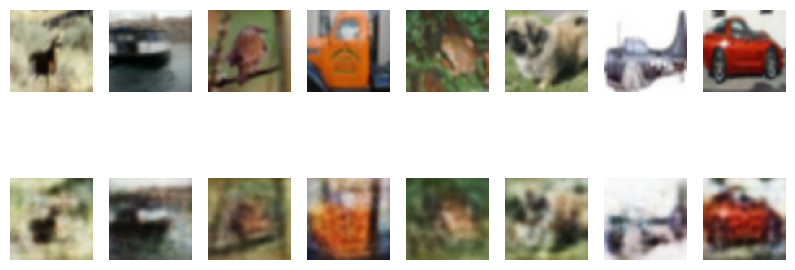

Visualizing Variational Autoencoder Reconstruction


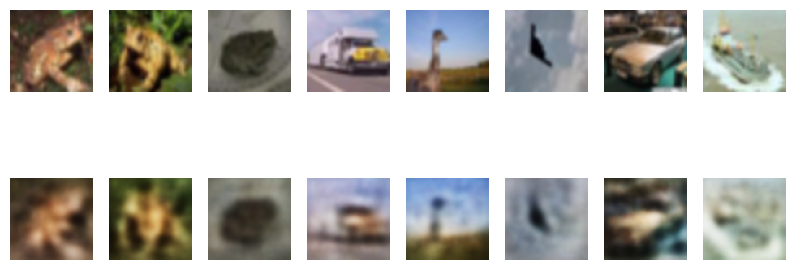

In [9]:
# Training
ae = Autoencoder(latent_dim=256)
vae = VariationalAutoencoder(latent_dim=256)

print("Training Autoencoder...")
train_autoencoder(ae, dataloader)
print("Training VAE...")
train_vae(vae, dataloader)

print("Visualizing Autoencoder Reconstruction")
visualize_reconstruction(ae, dataloader)

print("Visualizing Variational Autoencoder Reconstruction")
visualize_reconstruction(vae, dataloader, is_vae=True)

------

### Activation Function & Data Input Adjustments

1. Why does the current implementation use `ReLU()` in the encoder and `Tanh()` in the decoder? What would happen if you replaced `Tanh()` with `Sigmoid()`?

- `ReLU()` is used in the encoder because it introduces non-linearity while avoiding the vanishing gradient problem.
- The decoder uses `Tanh()` because it outputs values in the range $[-1,1]$, which is useful when reconstructing normalized images.

If we replace `Tanh()` with `Sigmoid()`, the output will be constrained to $[0,1]$. This can be beneficial for datasets where pixel values are normalized within this range, but for datasets centered around zero (e.g., using standard normalization), this might lead to suboptimal reconstructions.


2. If you use `LeakyReLU()` instead of `ReLU()` in the encoder, do you need to make any adjustments to the decoder? Why or why not?

No direct adjustments are needed in the decoder when switching to `LeakyReLU()`. `LeakyReLU()` is a modification of `ReLU()` that allows small negative gradients, preventing dead neurons. Since it mainly affects the encoding process, the decoder can still use `Tanh()` or another activation function without issue.


3. If you switch the decoder's activation function to `Sigmoid()`, what changes must be made to the `Normalize()` function in the dataset transformation?

If `Sigmoid()` is used in the decoder, the dataset transformation should ensure that pixel values are normalized within $[0,1]$ instead of $[-1,1]$. This means:

- If using `torchvision.transforms.Normalize(mean, std)`, adjust `mean` and `std` accordingly.
- If previously using `transforms.ToTensor()`, it might be sufficient since it already scales pixel values to $[0,1]$.
- If using `MinMaxScaler`, ensure it's scaling values to $[0,1]$.

---

### Latent Space & Reconstruction

4. In what scenarios would `LeakyReLU()` be a better choice than `ReLU()` in training Autoencoders or VAEs?

`LeakyReLU()` is preferable when:

- The dataset is complex, and neurons might become inactive due to `ReLU()`'s zero-gradient problem.
- The network is deep, and avoiding dead neurons is crucial.
- Training is unstable, and small gradients in negative regions improve convergence.

5. How would increasing the `latent_dim` from 128 to 256 affect the quality of reconstructed images?

Increasing `latent_dim` from 128 to 256 allows the model to capture more features, potentially improving image quality. However:

- It increases computational cost.
- If `latent_dim` is too large, the model might memorize training data instead of learning meaningful representations, reducing generalization.

---

### Loss Function & Optimization

6. In a Variational Autoencoder (VAE), why is reparameterization necessary, and how does it impact training stability?

Reparameterization is necessary because VAEs sample from a latent distribution, which is not differentiable. The trick expresses sampling as:

$$
z = \mu + \sigma \cdot \epsilon, \quad \text{where} \quad \epsilon \sim \mathcal{N}(0,1)
$$

This makes gradients flow through $\mu$ and $\sigma$, allowing backpropagation. It stabilizes training by ensuring meaningful latent space representations.

7. Currently, the Autoencoder uses `MSELoss()`. How would the results change if we used `BCEWithLogitsLoss()` instead?

- **`MSELoss()`** assumes pixel values follow a continuous distribution and penalizes squared errors.
- **`BCEWithLogitsLoss()`** assumes binary data and is better suited for pixel values in $[0,1]$.

Switching to `BCEWithLogitsLoss()` would:

- Require using `Sigmoid()` in the decoder.
- Change loss behavior: BCE treats each pixel as independent, while MSE penalizes differences proportionally.
- Sometimes lead to sharper reconstructions but may also introduce artifacts.

8. The optimizer used is `Adam()`. What would be the impact of switching to `SGD()` with momentum?

- **`Adam()`** adapts learning rates dynamically and is robust to poor initial conditions.
- **`SGD()` with momentum** helps smooth out updates but requires careful learning rate tuning.

Switching to `SGD()` with momentum may:

- Improve generalization but slow down convergence.
- Require a lower learning rate and tuning of momentum (e.g., 0.9) to prevent instability.
- Work better for larger datasets with a well-tuned learning rate.


---